# Coupled response: CESM3 / MOM6 experiment comparison

Diagnostics that only exist for the **coupled** experiments, because they
depend on the interactive atmosphere and sea-ice components (see
`Experiment.compute_ice`, `Experiment.compute_atm`,
`Experiment.compute_hfds_time_mean` in `experiment.py` — "atmospheric, ice,
and other variables not processed by ocean package mom6-tools", per
`CLAUDE.md`). The **forced** (ocean-only) experiments are still listed for
side-by-side comparison, but they have no interactive ice/atmosphere and no
computed `hfds`, so their panels below correctly show "no data".

**Experiments compared**

| name | mode | data folder |
|------|------|-------------|
| `CTRL` | coupled | `data/coupled_55years` |
| `coupled_bANN_1.0` | coupled | `data/coupled_55years` |
| `coupled_bANN_1.0_uANN_1.0` | coupled | `data/coupled_55years` |
| `forced_CTRL` | forced | `data/forced_55years` |
| `forced_bANN_1.0` | forced | `data/forced_55years` |
| `forced_bANN_1.0_uANN_1.0` | forced | `data/forced_55years` |

**Figures**

1. Sea ice volume (NH/SH) annual time series.
2. Sea ice thickness: GM state and parameterization response.
3. Sea ice extent: 15% concentration contour, every experiment's own state
   (no bias/response).
4. Air-sea heat flux (`hfds`): GM state and parameterization response.
5. Zonal-mean atmospheric temperature and zonal wind: GM state and
   parameterization response.
6. Meridional atmospheric heat transport (coupled only), diagnosed from the
   TOA/surface energy budget.

Heavy quantities are computed once through the `Experiment` class (methods
`compute_*`, reading the raw model history) and cached as
`<folder>/<name>_<metric>.nc`; the plotting cells only read those files.

**Kernel:** `env-from-npl-2024a` (Python 3.11.6).


In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import os

import numpy as np
import matplotlib.pyplot as plt
import cftime
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from experiment import Experiment

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams.update({'font.size': 18})

# Repo-root-relative paths (this notebook lives in <repo>/notebooks)
REPO = os.path.abspath(os.path.join(os.getcwd(), '..'))
YAML_DIR = os.path.join(REPO, 'yamls')
COUPLED_DIR = os.path.join(REPO, 'data', 'coupled_55years')
FORCED_DIR = os.path.join(REPO, 'data', 'forced_55years')
FIG_DIR = os.path.join(REPO, 'figures', 'coupled_55years')

print('REPO       =', REPO)
print('YAML_DIR   =', YAML_DIR)
print('COUPLED_DIR=', COUPLED_DIR)
print('FORCED_DIR =', FORCED_DIR)


ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/pavelp/conda-envs/env-from-npl-2024a/share/proj failed


REPO       = /glade/u/home/pavelp/m2lines-CESM3-diagnostics
YAML_DIR   = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/yamls
COUPLED_DIR= /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/coupled_55years
FORCED_DIR = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/forced_55years


## Initialize experiments (read-only)

Each experiment is defined by its `name`, the diagnostics YAML config, and the
folder holding its postprocessed NetCDF files. Initialization is read-only: it
only reads config + (best-effort) grid, and never triggers heavy computation.


In [2]:
# (name, folder) for each experiment. YAML config is yamls/<name>.yaml
experiment_defs = [
    ('CTRL',                        COUPLED_DIR),
    ('coupled_bANN_1.0',            COUPLED_DIR),
    ('coupled_bANN_1.0_uANN_1.0',   COUPLED_DIR),
    ('forced_CTRL',                 FORCED_DIR),
    ('forced_bANN_1.0',             FORCED_DIR),
    ('forced_bANN_1.0_uANN_1.0',    FORCED_DIR),
]

exps = {}
for name, folder in experiment_defs:
    yaml_path = os.path.join(YAML_DIR, f'{name}.yaml')
    exps[name] = Experiment(yaml_path, folder=folder, name=name,
                            load_grid=True, verbose=True)

exp_names = list(exps.keys())

# GM control first in each row, then the two ANN experiments.
coupled_names = ['CTRL', 'coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0']
forced_names = ['forced_CTRL', 'forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0']

print('\nInitialized:', exp_names)


[CTRL] casename=CTRL, rundir=/glade/derecho/scratch/jiarongw/CTRL/run
MOM6 grid successfully loaded... 

[coupled_bANN_1.0] casename=coupled_bANN_1.0, rundir=/glade/derecho/scratch/pavelp/coupled_bANN_1.0/run
MOM6 grid successfully loaded... 

[coupled_bANN_1.0_uANN_1.0] casename=coupled_bANN_1.0_uANN_1.0, rundir=/glade/derecho/scratch/pavelp/coupled_bANN_1.0_uANN_1.0/run
MOM6 grid successfully loaded... 

[forced_CTRL] casename=forced_CTRL, rundir=/glade/derecho/scratch/pavelp/forced_CTRL/run
MOM6 grid successfully loaded... 

[forced_bANN_1.0] casename=forced_bANN_1.0, rundir=/glade/derecho/scratch/pavelp/forced_bANN_1.0/run
MOM6 grid successfully loaded... 

[forced_bANN_1.0_uANN_1.0] casename=forced_bANN_1.0_uANN_1.0, rundir=/glade/derecho/scratch/pavelp/forced_bANN_1.0_uANN_1.0/run
MOM6 grid successfully loaded... 


Initialized: ['CTRL', 'coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0', 'forced_CTRL', 'forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0']


In [3]:
# Short legend labels (regime is shown in the panel title, so it is omitted here)
LABELS = {
    'CTRL':                       'GM',
    'coupled_bANN_1.0':           'bANN',
    'coupled_bANN_1.0_uANN_1.0':  'bANN_uANN',
    'forced_CTRL':                'GM',
    'forced_bANN_1.0':            'bANN',
    'forced_bANN_1.0_uANN_1.0':   'bANN_uANN',
}


# 1. Sea ice volume

Northern- and Southern-Hemisphere sea ice volume (`hi * area`, summed over
each hemisphere), monthly from `Experiment.compute_ice` and coarsened to
annual means here. Forced (ocean-only) experiments have no interactive sea
ice model, so their panels show "no data".

The first cell computes and caches `ice_volume_NH`/`ice_volume_SH` (plus the
time-mean `ice_thickness`/`ice_extent` maps used in Section 2) to
`<folder>/<name>_ice_volume.nc`; the second cell plots the time series.


In [7]:
# Compute (and cache) sea ice volume/thickness/extent for every experiment.
# Reads raw ice history -> heavy; skips experiments without ice output
# (forced/ocean-only runs have no interactive sea ice model).
for name in ['forced_bANN_1.0_uANN_1.0']:
    exp = exps[name]
    try:
        exp.compute_ice()
    except Exception as e:
        print(f'{name} skipped ({e})')


Reading dataset...
[########################################] | 100% Completed | 102.58 s
[########################################] | 100% Completed | 4.07 sms
[########################################] | 100% Completed | 1.52 sms
[########################################] | 100% Completed | 49.18 s


Exception ignored in: <function CachingFileManager.__del__ at 0x7f98455b1120>
Traceback (most recent call last):
  File "/glade/work/pavelp/conda-envs/env-from-npl-2024a/lib/python3.11/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/glade/work/pavelp/conda-envs/env-from-npl-2024a/lib/python3.11/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2627, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2590, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2034, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


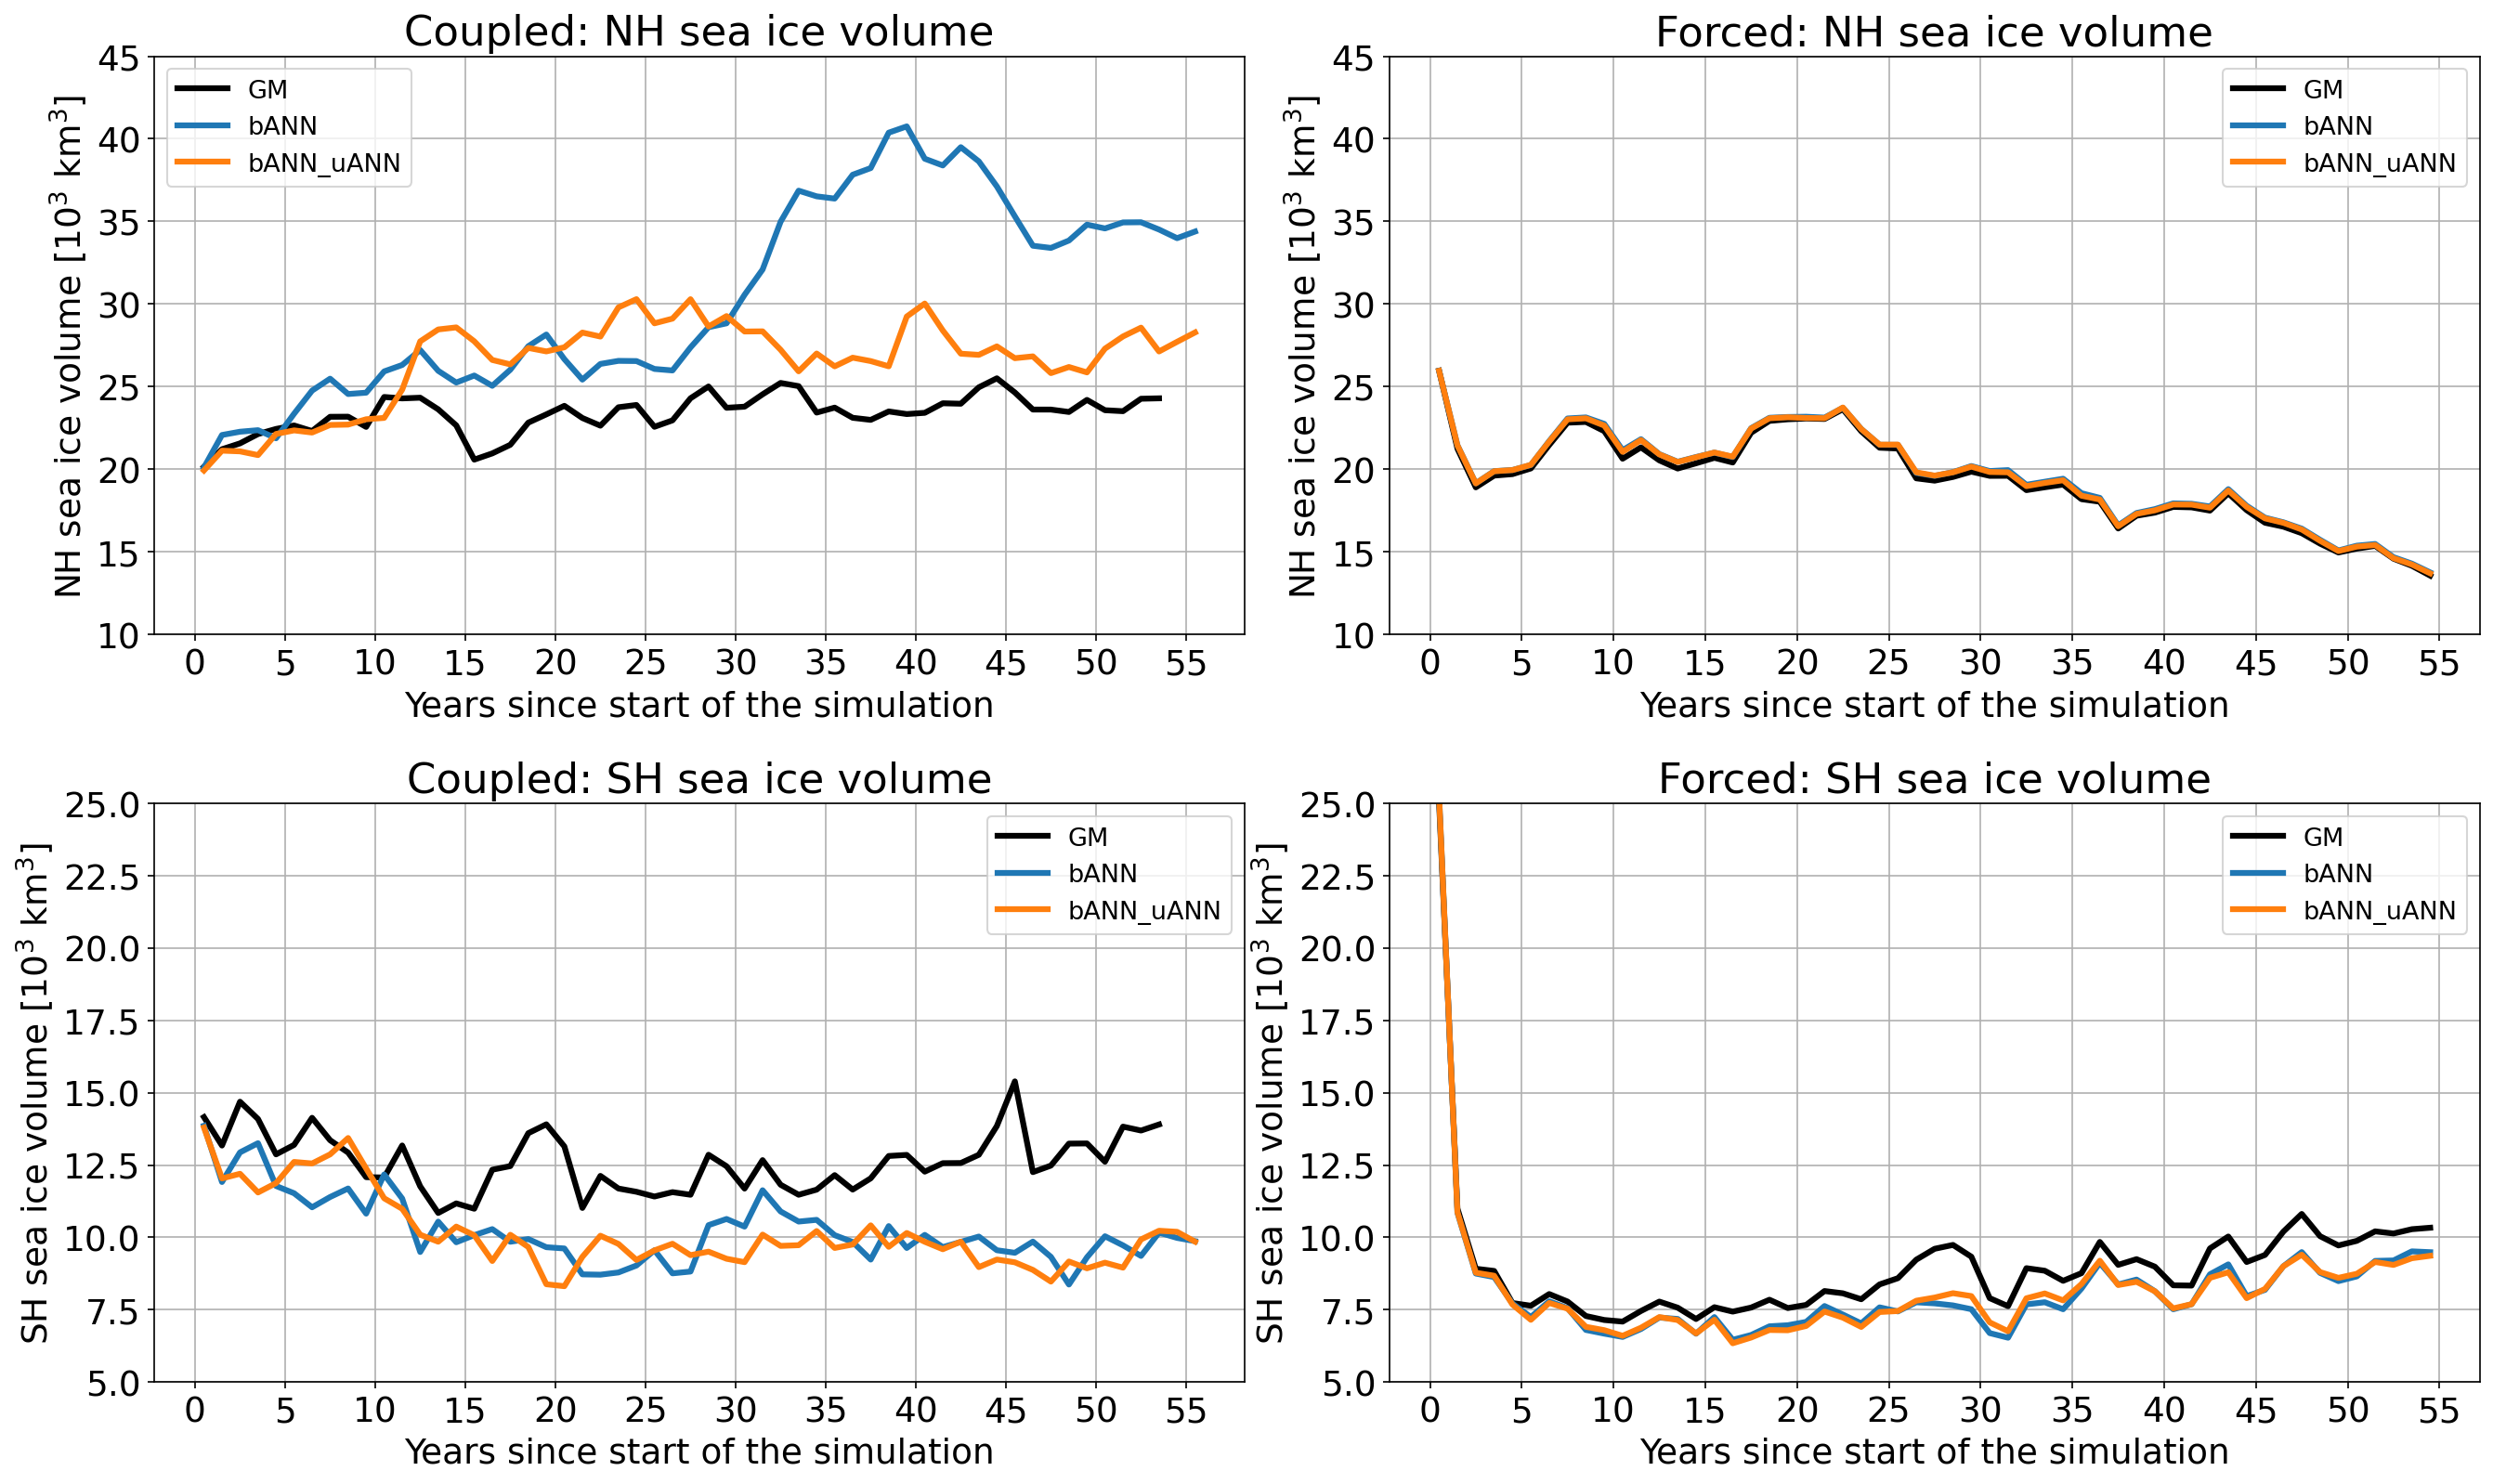

In [14]:
# Sea ice volume: 2x2 grid (rows = hemisphere, columns = regime).
# Monthly ice_volume_NH/SH -> annual mean, converted to 10^3 km^3.

ylim_NH = [10,45]
ylim_SH = [5, 25]

def _set_year_ticks(ax, times):
    # Label the time axis as years since the start of the simulation (5-year ticks).
    y0 = times[0].year
    years = list(range(y0, times[-1].year + 2, 5))
    ax.set_xticks([cftime.DatetimeNoLeap(y, 1, 1) for y in years])
    ax.set_xticklabels([y - y0 for y in years])
    ax.set_xlabel('Years since start of the simulation')


def plot_ice_volume(ax, names, hemisphere, title):
    # Annual-mean sea ice volume [10^3 km^3] for one hemisphere.
    ts = None
    for name in names:
        try:
            da = exps[name].ice_volume()[f'ice_volume_{hemisphere}']
        except (FileNotFoundError, OSError, KeyError):
            continue
        ts = (da / 1e12).coarsen(time=12).mean()
        is_ctrl = name.endswith('CTRL')
        ts.plot(ax=ax, label=LABELS[name], lw=3, color='k' if is_ctrl else None)
    if ts is None:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                transform=ax.transAxes, fontsize=14)
        ax.set_title(title)
        return
    _set_year_ticks(ax, ts.time.values)
    ax.set_title(title)
    ax.set_ylabel(f'{hemisphere} sea ice volume [$10^3$ km$^3$]')
    ax.grid(True)
    ax.legend(loc='best', fontsize=13)


fig, axes = plt.subplots(2, 2, figsize=(18, 11), dpi=150)
plot_ice_volume(axes[0, 0], coupled_names, 'NH', 'Coupled: NH sea ice volume')
plot_ice_volume(axes[0, 1], forced_names, 'NH', 'Forced: NH sea ice volume')
plot_ice_volume(axes[1, 0], coupled_names, 'SH', 'Coupled: SH sea ice volume')
plot_ice_volume(axes[1, 1], forced_names, 'SH', 'Forced: SH sea ice volume')
axes[0,0].set_ylim(ylim_NH)
axes[0,1].set_ylim(ylim_NH)
axes[1,0].set_ylim(ylim_SH)
axes[1,1].set_ylim(ylim_SH)

plt.tight_layout()
plt.show()


# 2. Sea ice thickness response

Time-mean sea ice thickness (`hi`, years 31-54), reusing the cache from
Section 1 (`<folder>/<name>_ice_volume.nc`). The ice grid coincides with the
ocean tracer grid (`yh`, `xh`), so it is plotted on `grd.geolon`/`geolat`
like the other surface maps in `dynamics.ipynb`.

- **Left column:** GM ice thickness (own colour scale).
- **Two right columns:** response (`experiment - GM`), separate `RdBu_r`
  colour scale.

Forced (ocean-only) panels show "no data".


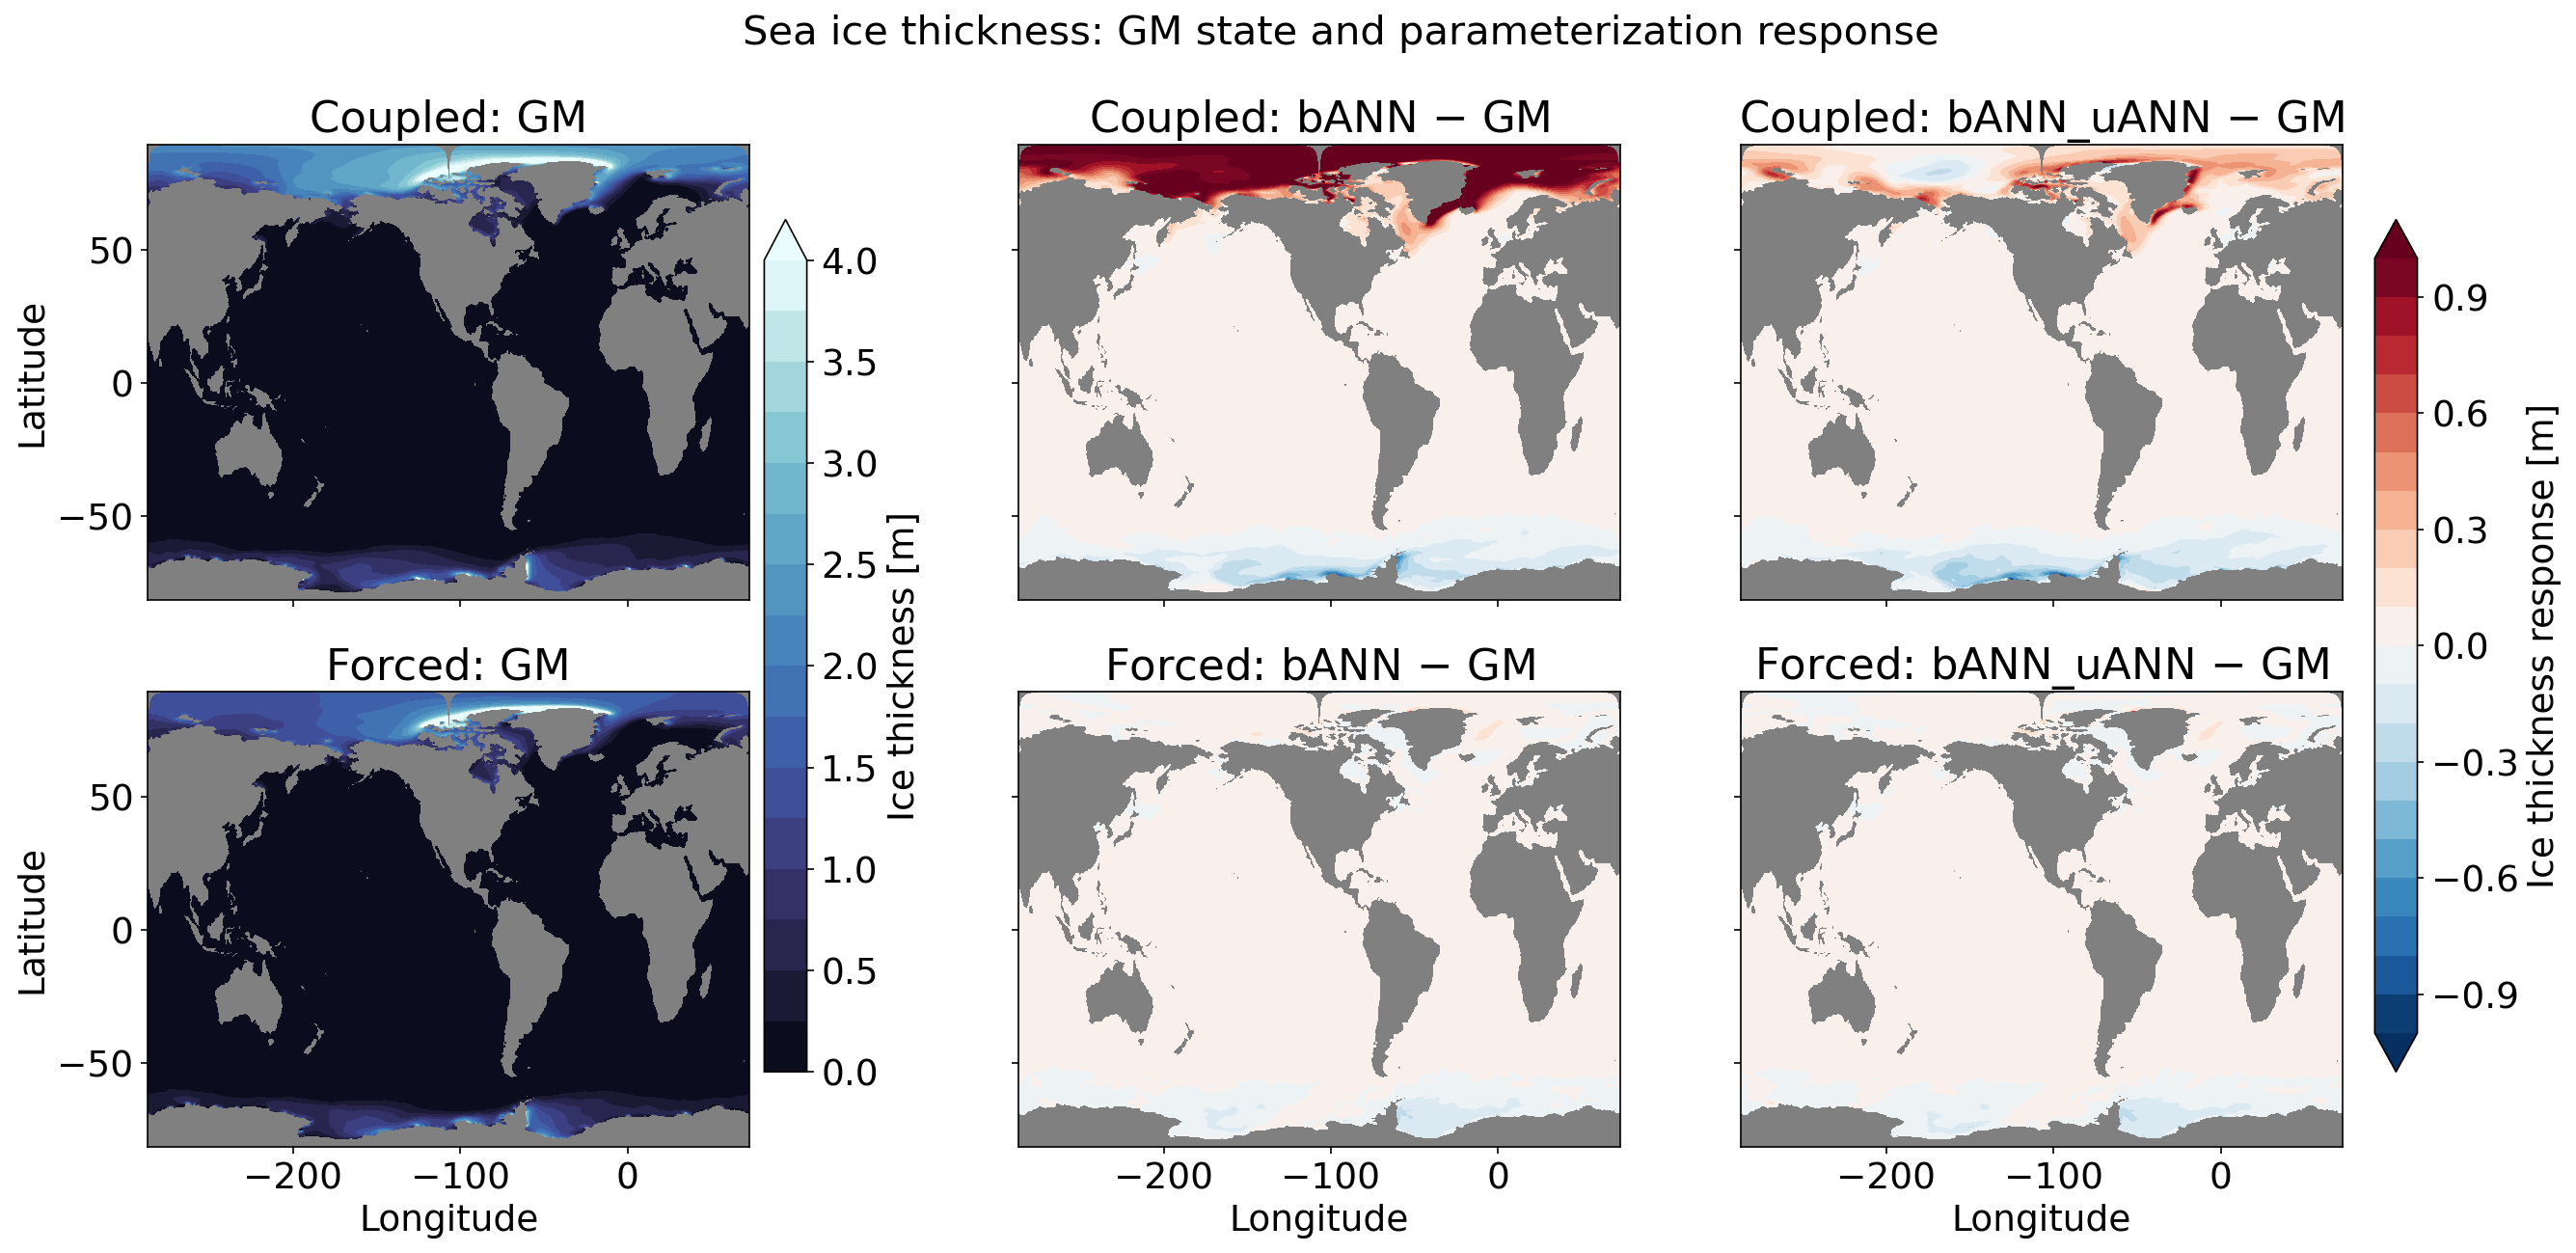

In [5]:
ICE_LEVELS = np.arange(0, 4.01, 0.25)          # m (GM state)
ICE_RESP_LEVELS = np.arange(-1.0, 1.01, 0.1)   # m (response)

fig, axes = plt.subplots(2, 3, figsize=(22, 9), dpi=150,
                         sharex=True, sharey=True)
cf_ice = None
cf_resp = None
for row, (regime, names) in enumerate([('Coupled', coupled_names),
                                       ('Forced', forced_names)]):
    gm_name = names[0]
    try:
        gm_thick = exps[gm_name].ice_volume()['ice_thickness']
    except (FileNotFoundError, OSError, KeyError):
        gm_thick = None
    for col, name in enumerate(names):
        ax = axes[row, col]
        ax.set_facecolor('gray')
        grd = exps[name].grd
        try:
            if col == 0:
                field = exps[name].ice_volume()['ice_thickness']
                cf_ice = ax.contourf(grd.geolon, grd.geolat, field,
                                     levels=ICE_LEVELS, cmap=cmocean.cm.ice,
                                     extend='max')
                title = f'{regime}: {LABELS[name]}'
            else:
                field = exps[name].ice_volume()['ice_thickness'] - gm_thick
                cf_resp = ax.contourf(grd.geolon, grd.geolat, field,
                                      levels=ICE_RESP_LEVELS, cmap='RdBu_r',
                                      extend='both')
                title = f'{regime}: {LABELS[name]} ' + r'$-$' + ' GM'
        except (FileNotFoundError, OSError, KeyError, TypeError):
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, color='white', fontsize=14)
            title = f'{regime}: {LABELS[name]}'
        ax.set_title(title)
        ax.set_xlabel('Longitude' if row == 1 else '')
        ax.set_ylabel('Latitude' if col == 0 else '')
if cf_ice is not None:
    fig.colorbar(cf_ice, ax=axes[:, 0], label='Ice thickness [m]',
                 extend='max', shrink=0.85, pad=0.02)
if cf_resp is not None:
    fig.colorbar(cf_resp, ax=axes[:, 1:], label='Ice thickness response [m]',
                 extend='both', shrink=0.85, pad=0.02)
fig.suptitle('Sea ice thickness: GM state and parameterization response',
             fontsize=20)
plt.show()


# 3. Sea ice extent

Sea ice extent, shown as the **15% ice-concentration contour line** (`aice`
from the same `<folder>/<name>_ice_volume.nc` cache as Sections 1-2) --
i.e. the ice edge, not a filled field. Every experiment's own state is drawn
directly (**no bias or response**), overlaid for direct comparison on
North/South Polar Stereographic maps with coastlines (Cartopy) -- a plain
lon/lat contour breaks at the tripolar grid's Arctic seam, while the polar
projection closes the circumpolar ice edge correctly. Colour by
parameterization (GM / bANN / bANN_uANN), solid for coupled and dashed for
forced. Forced (ocean-only) experiments have no interactive sea ice, so in
practice only the three coupled edges are drawn today; the legend only
lists whatever actually has data.


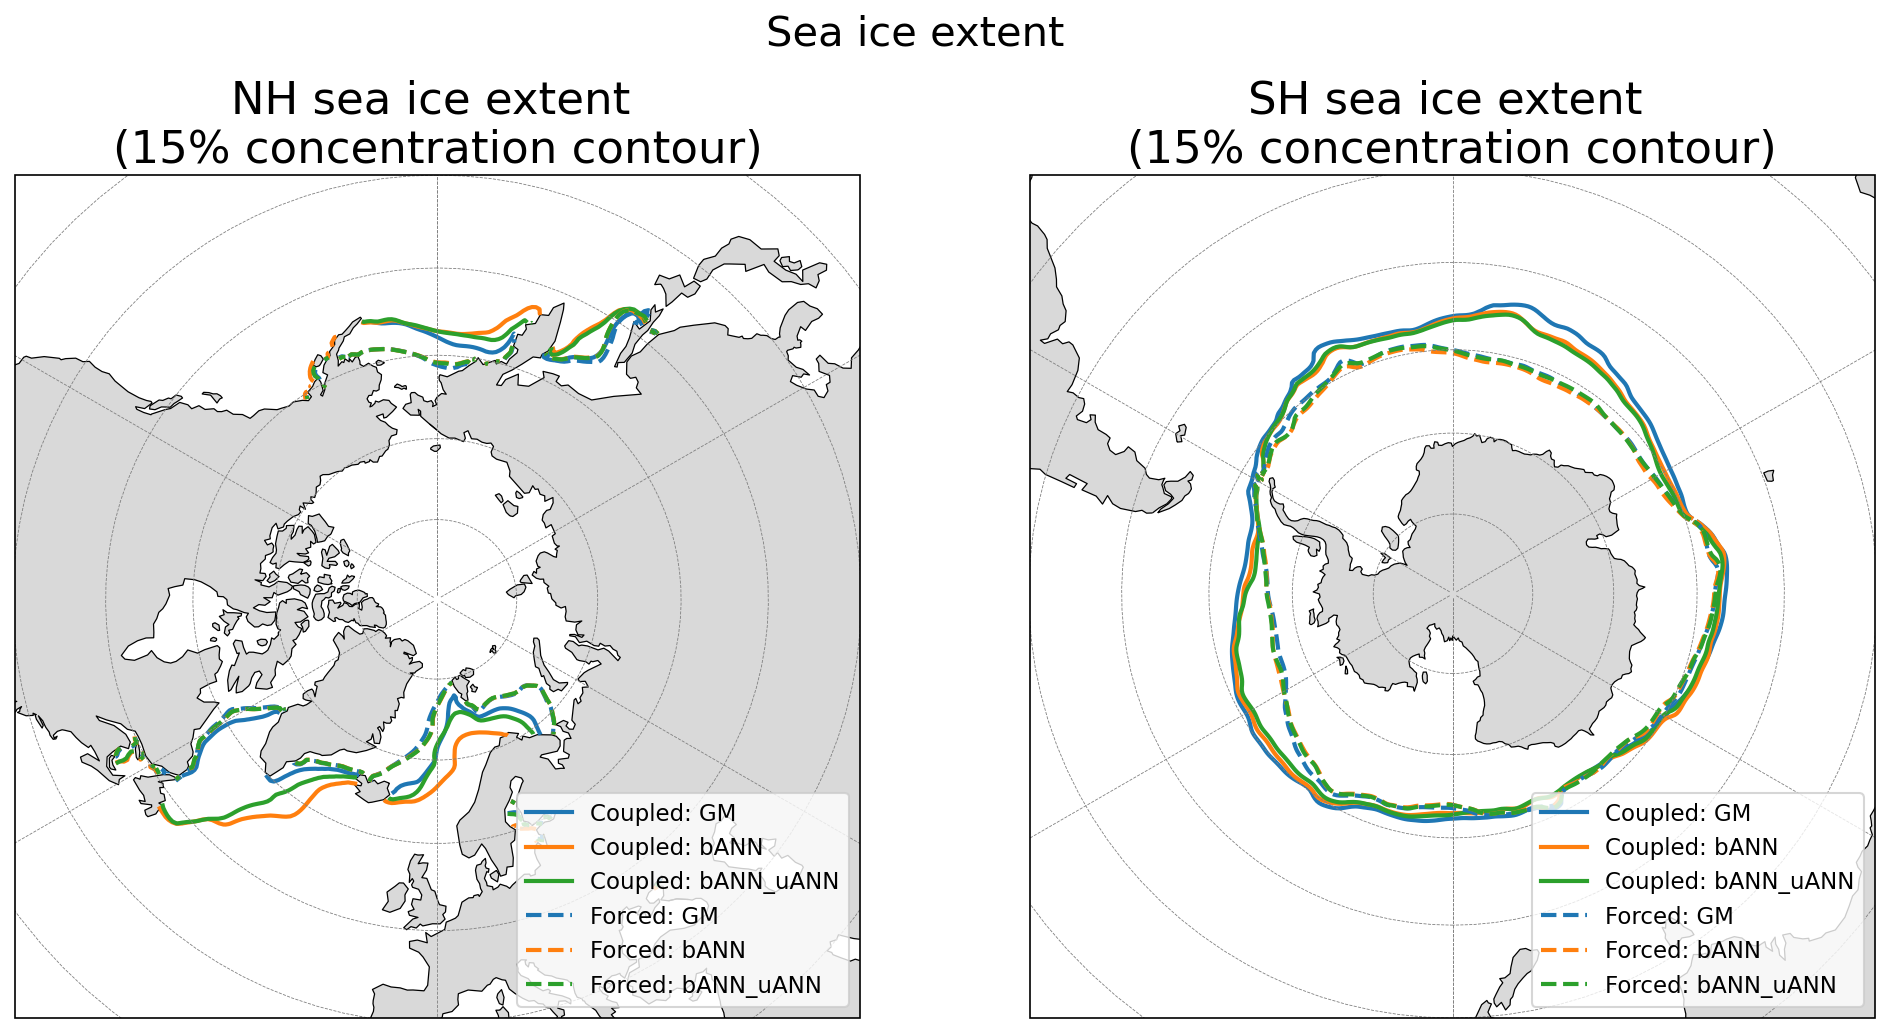

In [26]:
# Sea ice extent (15% concentration contour) for every experiment, no
# bias/response -- reuses the ice_extent cache from Section 1/2. Plotted on
# North/South Polar Stereographic maps (Cartopy) with coastlines: a flat
# lon/lat contour breaks at the tripolar grid's Arctic seam, while the polar
# projection correctly closes the circumpolar ice edge. Colour by
# parameterization (GM/bANN/bANN_uANN), linestyle by regime (solid=coupled,
# dashed=forced). Legend entries are built dynamically from whatever
# actually plotted, so forced experiments (currently no ice data) simply
# do not appear.
import cartopy.crs as ccrs
import cartopy.feature as cfeature

ICE_EXTENT_LEVEL = 0.15   # standard 15% sea-ice concentration threshold
EXTENT_COLORS = {'GM': 'tab:blue', 'bANN': 'tab:orange', 'bANN_uANN': 'tab:green'}
EXTENT_STYLES = {'Coupled': '-', 'Forced': '--'}

fig = plt.figure(figsize=(16, 8), dpi=150)
hemispheres = [('NH', ccrs.NorthPolarStereo(), 40, 90),
              ('SH', ccrs.SouthPolarStereo(), -90, -40)]
for i, (hemi, proj, lat0, lat1) in enumerate(hemispheres):
    ax = fig.add_subplot(1, 2, i + 1, projection=proj)
    ax.set_extent([-180, 180, lat0, lat1], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='0.85', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.gridlines(linestyle='--', linewidth=0.4, color='gray')
    plotted = {}
    for regime, names in [('Coupled', coupled_names), ('Forced', forced_names)]:
        for name in names:
            try:
                extent = exps[name].ice_volume()['ice_extent']
            except (FileNotFoundError, OSError, KeyError):
                continue
            grd = exps[name].grd
            color = EXTENT_COLORS[LABELS[name]]
            ls = EXTENT_STYLES[regime]
            ax.contour(grd.geolon, grd.geolat, extent,
                      levels=[ICE_EXTENT_LEVEL], colors=color,
                      linestyles=ls, linewidths=2,
                      transform=ccrs.PlateCarree())
            plotted[(regime, LABELS[name])] = (color, ls)
    handles = [plt.Line2D([0], [0], color=c, lw=2, ls=ls, label=f'{regime}: {label}')
               for (regime, label), (c, ls) in plotted.items()]
    if handles:
        ax.legend(handles=handles, loc='lower right', fontsize=11)
    ax.set_title(f'{hemi} sea ice extent \n(15% concentration contour)')
fig.suptitle('Sea ice extent',
             fontsize=20)
plt.show()


# 4. Air-sea heat flux (hfds)

Time-mean downward surface heat flux into the ocean (`hfds`, W m$^{-2}$,
positive downward), from `Experiment.compute_hfds_time_mean`.

- **Left column:** GM state.
- **Two right columns:** response (`experiment - GM`), separate `RdBu_r`
  colour scale with a narrower range than the GM state.

Forced (ocean-only) panels show "no data" (`hfds` is not currently cached
for the forced experiments).

The first cell computes and caches `hfds` to
`<folder>/<name>_hfds_time_mean.nc`; the second plots it.


In [8]:
# Compute (and cache) the time-mean surface heat flux for every experiment.
# Reads raw native history -> heavy; skips cached / missing.
for name in ['forced_CTRL', 'forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0']:
    exp = exps[name]
    try:
        exp.compute_hfds_time_mean()
    except Exception as e:
        print(f'{name} skipped ({e})')


[########################################] | 100% Completed | 44.15 s


Exception ignored in: <function CachingFileManager.__del__ at 0x7f98455b1120>
Traceback (most recent call last):
  File "/glade/work/pavelp/conda-envs/env-from-npl-2024a/lib/python3.11/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/glade/work/pavelp/conda-envs/env-from-npl-2024a/lib/python3.11/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2627, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2590, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2034, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


[########################################] | 100% Completed | 50.00 s
[########################################] | 100% Completed | 48.29 s


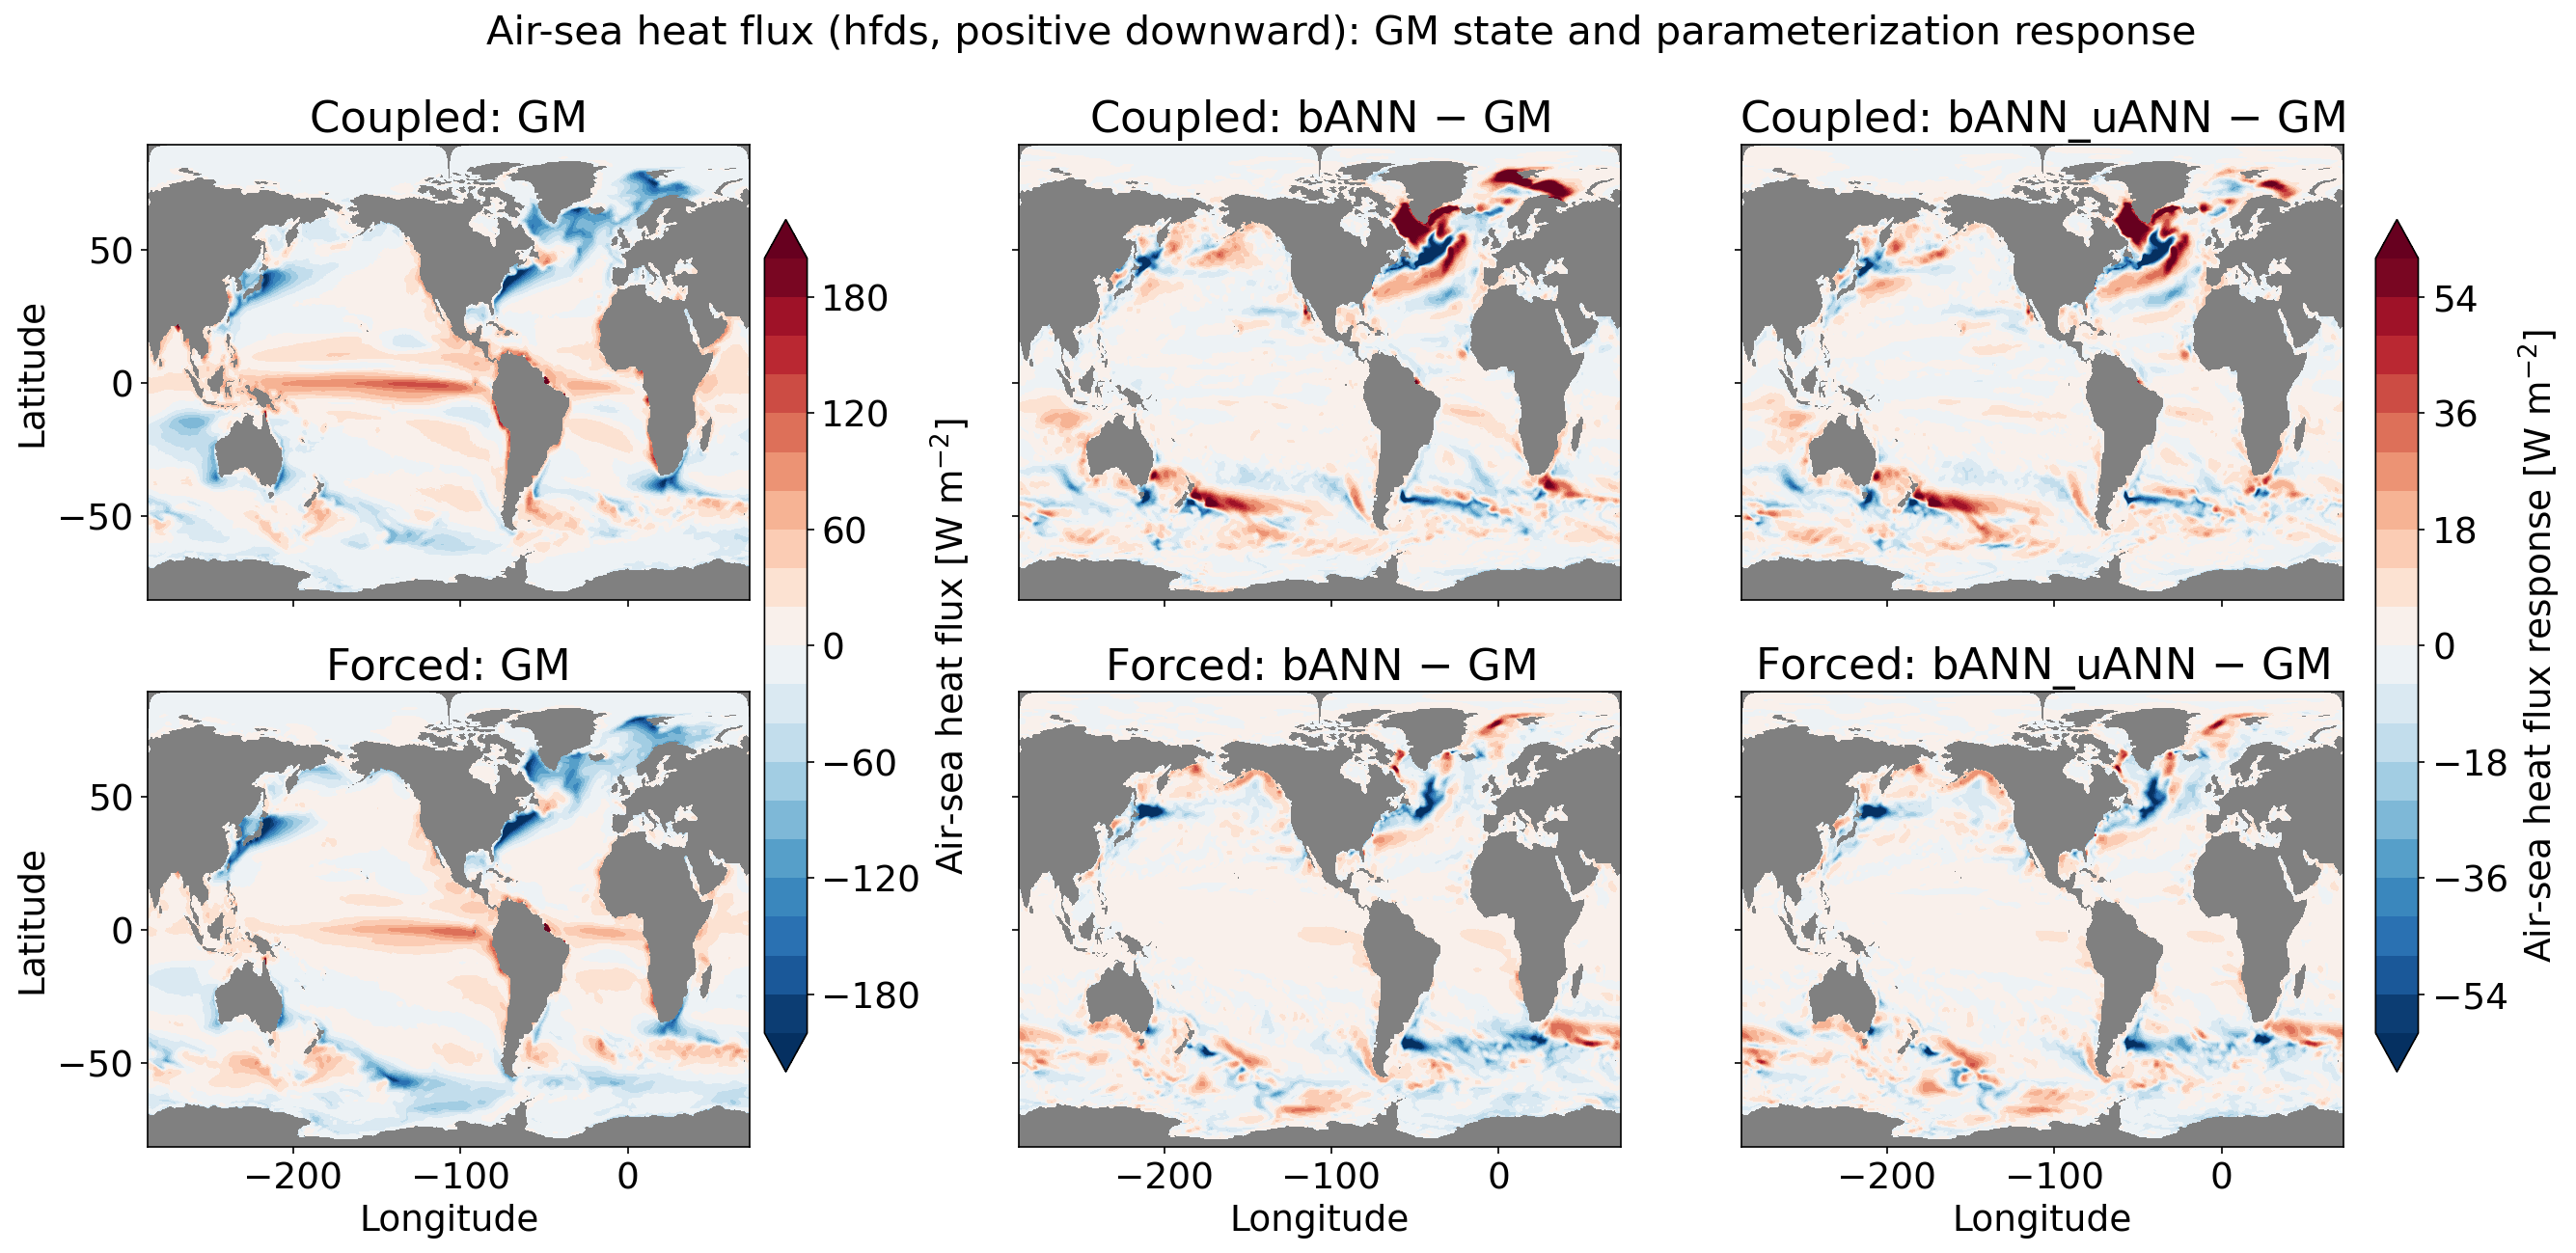

In [10]:
HFDS_LEVELS = np.arange(-200, 201, 20)        # W/m^2 (GM state)
HFDS_RESP_LEVELS = np.arange(-60, 61, 6)      # W/m^2 (response)

fig, axes = plt.subplots(2, 3, figsize=(22, 9), dpi=150,
                         sharex=True, sharey=True)
cf_hfds = None
cf_resp = None
for row, (regime, names) in enumerate([('Coupled', coupled_names),
                                       ('Forced', forced_names)]):
    gm_name = names[0]
    try:
        gm_hfds = exps[gm_name].hfds_time_mean()
    except (FileNotFoundError, OSError, KeyError):
        gm_hfds = None
    for col, name in enumerate(names):
        ax = axes[row, col]
        ax.set_facecolor('gray')
        grd = exps[name].grd
        try:
            if col == 0:
                field = exps[name].hfds_time_mean()
                cf_hfds = ax.contourf(grd.geolon, grd.geolat, field,
                                      levels=HFDS_LEVELS, cmap='RdBu_r',
                                      extend='both')
                title = f'{regime}: {LABELS[name]}'
            else:
                field = exps[name].hfds_time_mean() - gm_hfds
                cf_resp = ax.contourf(grd.geolon, grd.geolat, field,
                                      levels=HFDS_RESP_LEVELS, cmap='RdBu_r',
                                      extend='both')
                title = f'{regime}: {LABELS[name]} ' + r'$-$' + ' GM'
        except (FileNotFoundError, OSError, KeyError, TypeError):
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, color='white', fontsize=14)
            title = f'{regime}: {LABELS[name]}'
        ax.set_title(title)
        ax.set_xlabel('Longitude' if row == 1 else '')
        ax.set_ylabel('Latitude' if col == 0 else '')
if cf_hfds is not None:
    fig.colorbar(cf_hfds, ax=axes[:, 0], label='Air-sea heat flux [W m$^{-2}$]',
                 extend='both', shrink=0.85, pad=0.02)
if cf_resp is not None:
    fig.colorbar(cf_resp, ax=axes[:, 1:], label=r'Air-sea heat flux response [W m$^{-2}$]',
                 extend='both', shrink=0.85, pad=0.02)
fig.suptitle('Air-sea heat flux (hfds, positive downward): GM state and parameterization response',
             fontsize=20)
plt.show()


# 5. Atmospheric response: zonal-mean temperature and zonal wind

Zonal-mean, time-mean atmospheric potential temperature (`T`) and zonal wind
(`U`) as pressure-latitude cross sections, from `Experiment.compute_atm`
(CAM history, years 31-54).

- **Left column:** GM state.
- **Two right columns:** response (`experiment - GM`), separate `RdBu_r`
  colour scale.

Forced (ocean-only) panels show "no data" (no interactive atmosphere).

The first cell computes and caches `T_mean`/`U_mean`/`TS_mean` to
`<folder>/<name>_atm_time_mean.nc`; the second plots the two cross sections.


In [ ]:
# Compute (and cache) the zonal-mean atmospheric state for every experiment.
# Reads raw CAM history -> heavy; skips experiments without atmosphere output
# (forced/ocean-only runs have no interactive atmosphere).
# NOTE: compute_atm() now also derives atm_heat_transport (Section 6) --
# re-running it for the coupled experiments (already cached before that was
# added) is required to populate that variable in their atm_time_mean.nc.
for name in exp_names:
    exp = exps[name]
    try:
        exp.compute_atm()
    except Exception as e:
        print(f'{name} skipped ({e})')

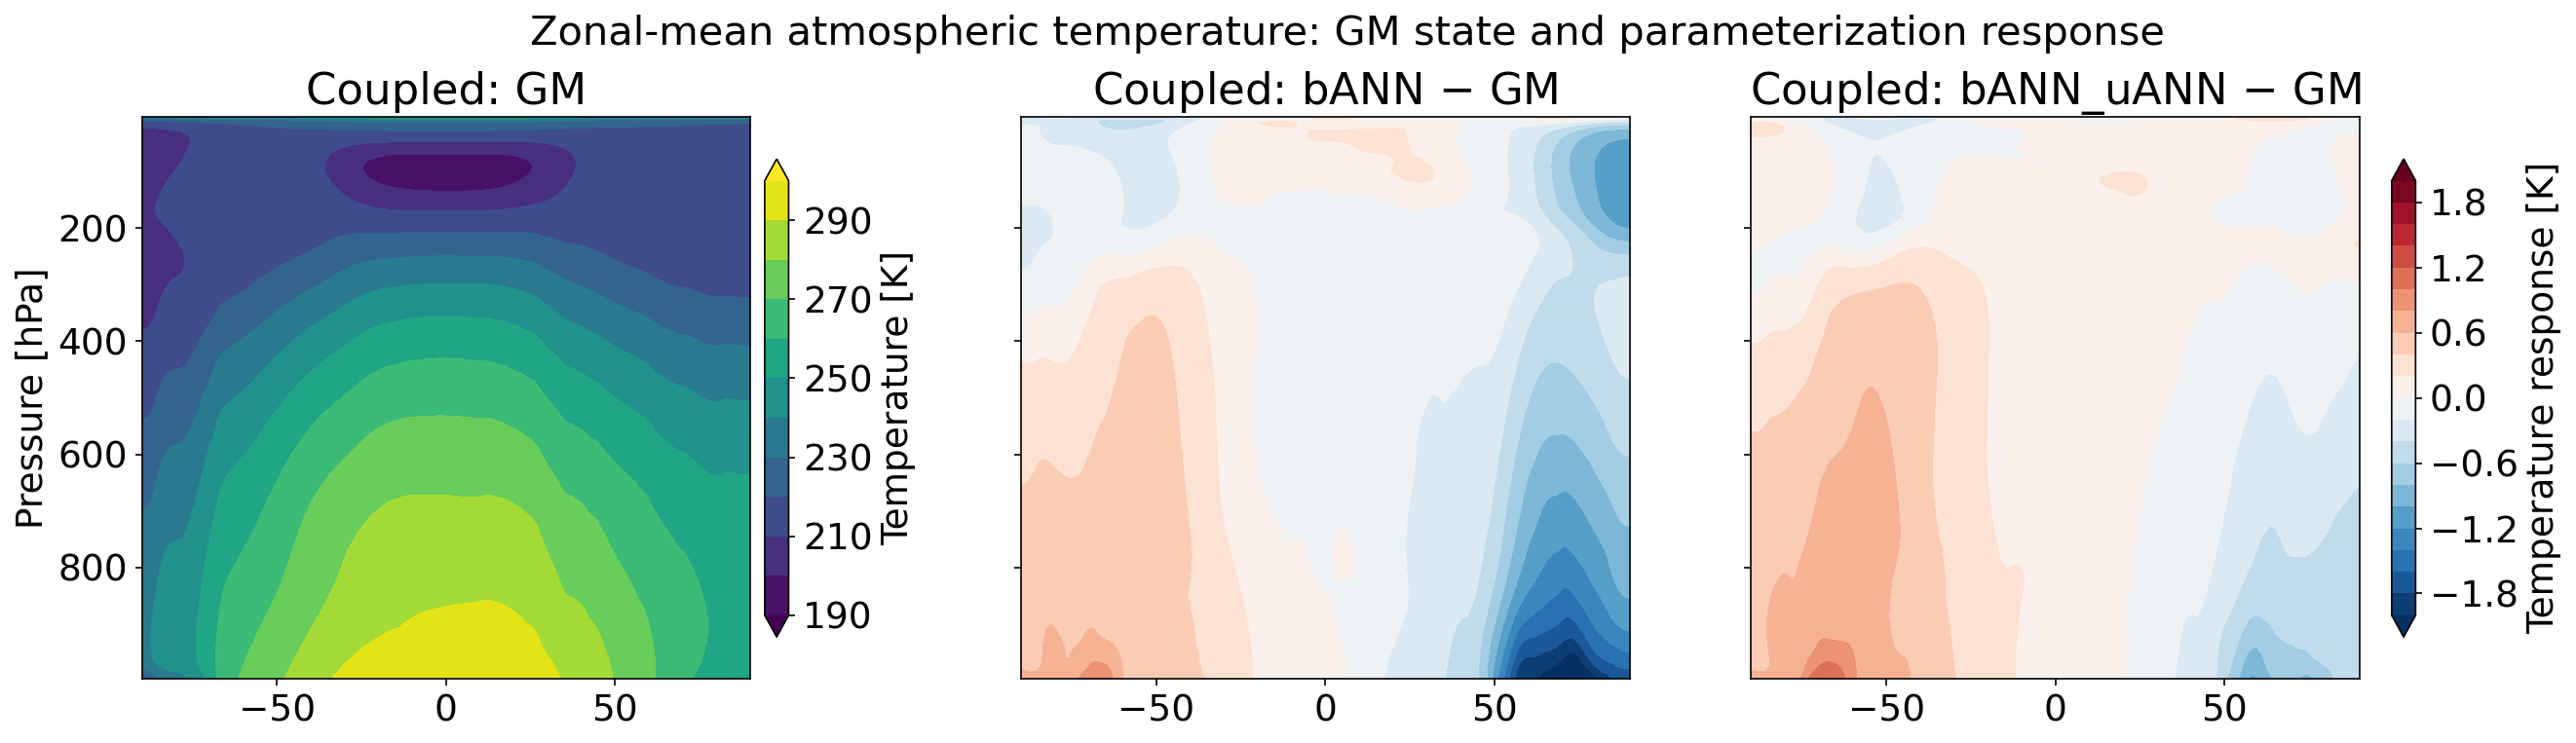

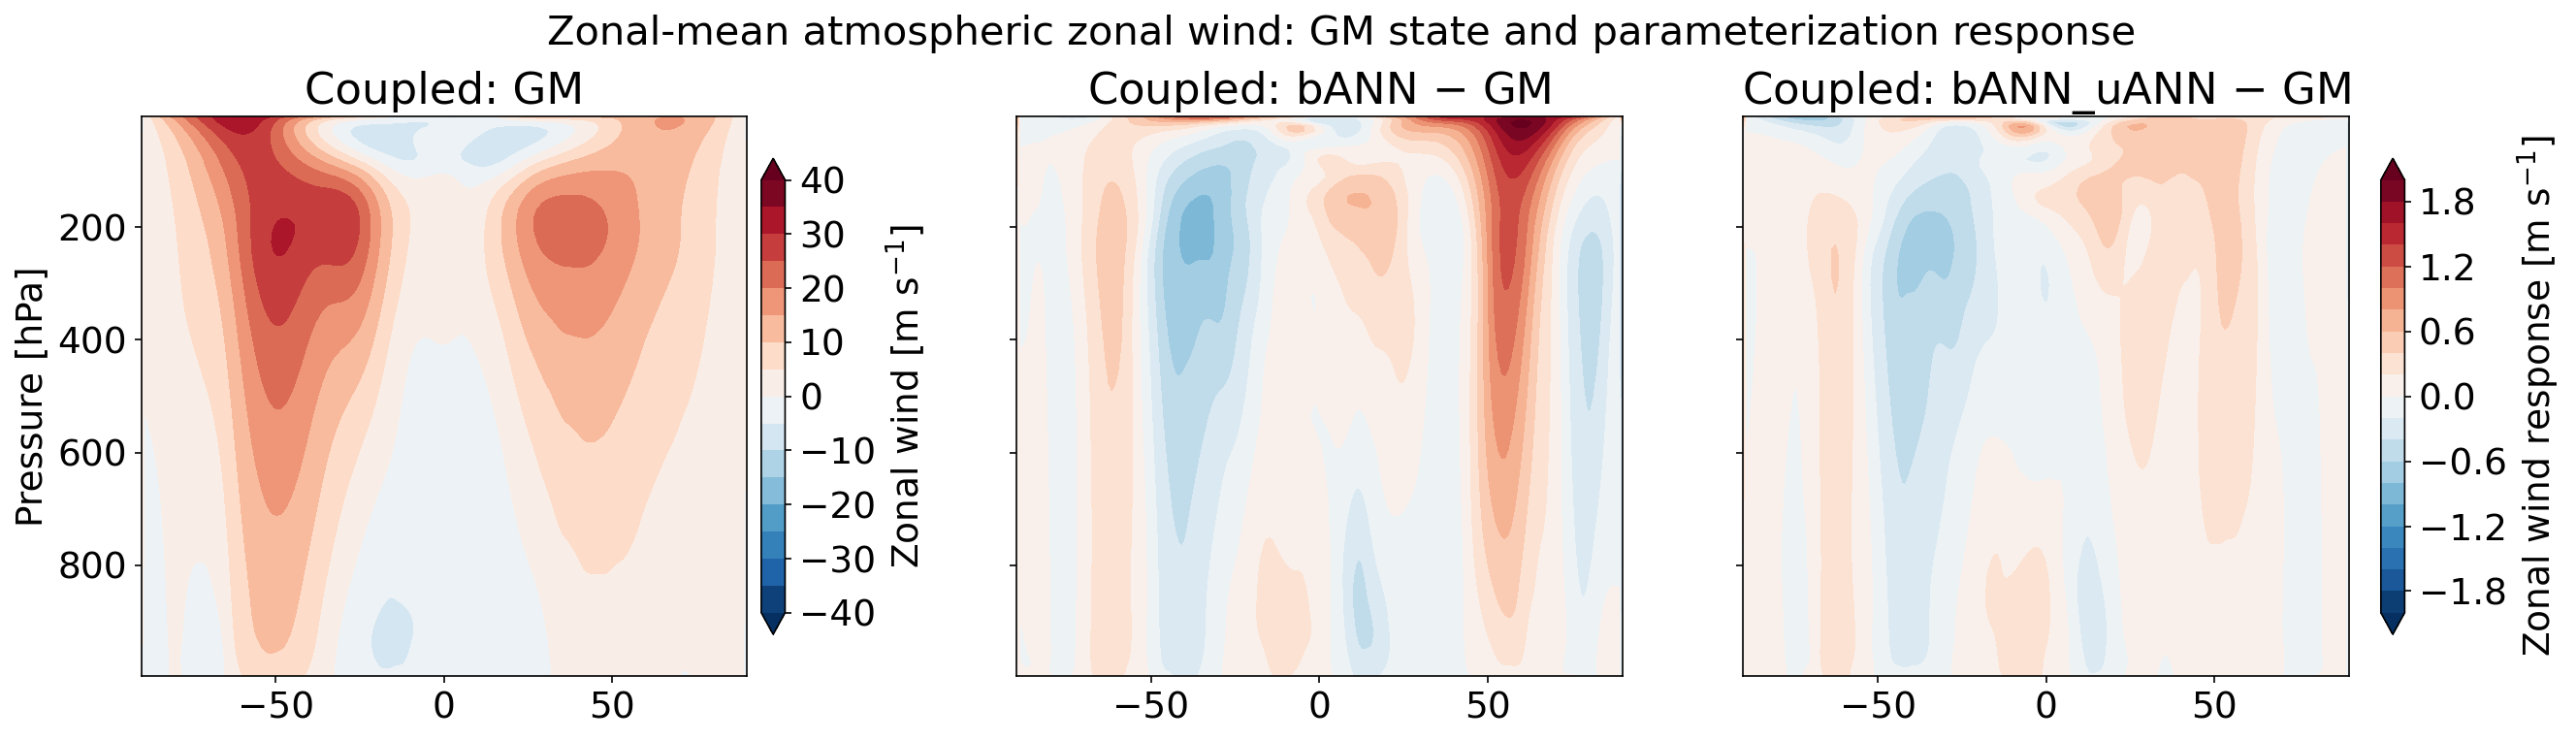

In [20]:
# Generic GM-state / response plotter for a zonal-mean atmospheric cross
# section (pressure vs latitude), reused for temperature and zonal wind.

def plot_atm_response(var, gm_levels, gm_cmap, resp_levels, quantity, unit):
    fig, axes = plt.subplots(1, 3, figsize=(22, 5), dpi=150,
                             sharex=True, sharey=True)
    cf_abs = None
    cf_resp = None
    for row, (regime, names) in enumerate([('Coupled', coupled_names)]):
        gm_name = names[0]
        try:
            gm_field = exps[gm_name].atm_mean()[var]
        except (FileNotFoundError, OSError, KeyError):
            gm_field = None
        for col, name in enumerate(names):
            ax = axes[col]
            try:
                if col == 0:
                    field = exps[name].atm_mean()[var]
                    cf_abs = ax.contourf(field['lat'], field['lev'], field,
                                         levels=gm_levels, cmap=gm_cmap,
                                         extend='both')
                    title = f'{regime}: {LABELS[name]}'
                else:
                    field = exps[name].atm_mean()[var] - gm_field
                    cf_resp = ax.contourf(field['lat'], field['lev'], field,
                                          levels=resp_levels, cmap='RdBu_r',
                                          extend='both')
                    title = f'{regime}: {LABELS[name]} ' + r'$-$' + ' GM'
            except (FileNotFoundError, OSError, KeyError, TypeError):
                ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                        transform=ax.transAxes, fontsize=14)
                title = f'{regime}: {LABELS[name]}'
            ax.set_title(title)
            ax.set_xlabel('Latitude' if row == 1 else '')
            ax.set_ylabel('Pressure [hPa]' if col == 0 else '')
    axes[0].invert_yaxis()   # shared y-axis: propagates to every panel
    if cf_abs is not None:
        fig.colorbar(cf_abs, ax=axes[0], label=f'{quantity} [{unit}]',
                     extend='both', shrink=0.85, pad=0.02)
    if cf_resp is not None:
        fig.colorbar(cf_resp, ax=axes[1:], label=f'{quantity} response [{unit}]',
                     extend='both', shrink=0.85, pad=0.02)
    fig.suptitle(f'Zonal-mean atmospheric {quantity.lower()}: GM state and '
                 'parameterization response', fontsize=20, y=1.02)
    plt.show()


plot_atm_response('T_mean', np.arange(190, 301, 10), 'viridis',
                  np.arange(-2, 2.1, 0.2), 'Temperature', 'K')
plot_atm_response('U_mean', np.arange(-40, 41, 5), 'RdBu_r',
                  np.arange(-2, 2.1, 0.2), 'Zonal wind', 'm s$^{-1}$')


# 6. Meridional atmospheric heat transport (coupled only)

The atmospheric heat transport is not directly simulated -- it is
**diagnosed from the column energy budget** (`Experiment.compute_atm`,
`inferred_heat_transport` in `experiment.py`): the cumulative meridional
integral of the zonal- and time-mean net energy imbalance of the
atmospheric column,

$$\text{TOA net} - \text{surface net} = (\text{FSNT}-\text{FLNT}) -
(\text{FSNS}-\text{LHFLX}-\text{SHFLX}-\text{FLNS}),$$

i.e. however much net energy enters the column at the TOA that isn't
accounted for at the surface must be carried away (or in) by atmospheric
transport. Positive/negative values are northward/southward transport [PW].

Coupled only: no interactive atmosphere in the forced (ocean-only) runs.
Reuses the `atm_time_mean.nc` cache from Section 5 -- no new heavy
computation beyond re-running `compute_atm` once to add this variable.


In [4]:
# Compute (and cache) the diagnosed meridional atmospheric heat transport
# for the coupled experiments. Reads raw CAM history -> heavy; this is the
# same Experiment.compute_atm call as Section 5 (also (re-)writes
# TS_mean/T_mean/U_mean there), scoped here to coupled_names since the
# heat transport is coupled-only.
for name in coupled_names:
    exp = exps[name]
    try:
        exp.compute_atm()
    except Exception as e:
        print(f'{name} skipped ({e})')


coupled_bANN_1.0_uANN_1.0 skipped ([Errno 2] No such file or directory: '/glade/derecho/scratch/pavelp/archive/coupled_bANN_1.0_uANN_1.0/atm/hist/coupled_bANN_1.0_uANN_1.0.cam.h0a.0031-01.nc')


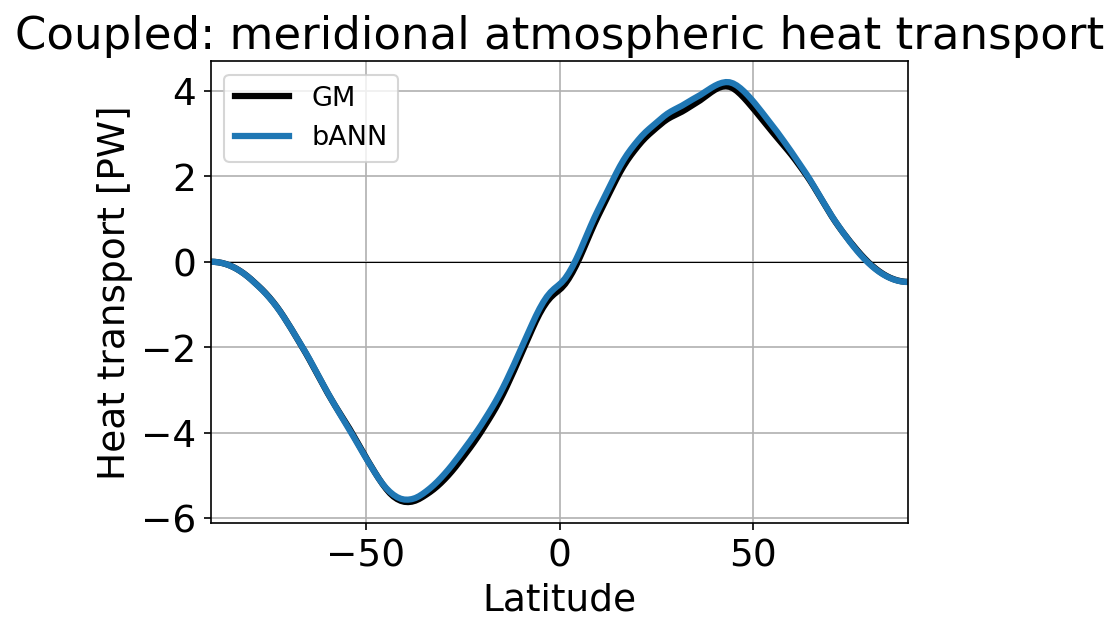

In [6]:
# Meridional atmospheric heat transport (coupled only), diagnosed from the
# TOA/surface energy budget (Experiment.compute_atm -> atm_heat_transport).
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
ax.axhline(0.0, color='k', lw=0.5)
for name in coupled_names:
    try:
        ht = exps[name].atm_mean()['atm_heat_transport']
    except (FileNotFoundError, OSError, KeyError):
        continue
    is_ctrl = name.endswith('CTRL')
    ht.plot(ax=ax, label=LABELS[name], lw=3, color='k' if is_ctrl else None)
ax.set_xlim(-90, 90)
ax.set_title('Coupled: meridional atmospheric heat transport')
ax.set_xlabel('Latitude')
ax.set_ylabel('Heat transport [PW]')
ax.grid(True)
ax.legend(loc='best', fontsize=13)
plt.show()
